# 09 – Steuerung (Bedingungen, Verzweigungen)

Hier lernst du **Verzweigungen** kennen: Abhängig von einer **Bedingung** wird unterschiedlicher Code ausgeführt – `if`, `elif`, `else`. In Python gibt es keine `switch`/`case`-Anweisung wie in C; stattdessen nutzt du **if/elif/else**. Wir vergleichen die Syntax mit C und wenden sie auf ein **fachliches Beispiel** an: Sinussignal mit optionalem Rauschen (AWGN), gesteuert durch eine Variable **NOISY**.

**Navigation:** [← 08_Zufallszahlen](../08_Zufallszahlen/08_Zufallszahlen.ipynb) | 09_Steuerung | [→ 10_Tupels](../10_Tupels/10_Tupels.ipynb)

## Der Datentyp `bool` (Boolean)

Bedingungen liefern einen Wert vom Typ **`bool`**: entweder **`True`** oder **`False`**. Du kannst solche Werte in Variablen speichern – z. B. **NOISY** für „soll Rauschen zugemischt werden?“. So wird der Programmablauf lesbar: `if NOISY:` statt `if noisy == 1`.

In Python schreibst du **`True`** und **`False`** mit großem Anfangsbuchstaben (in C wären es oft `1` und `0` oder ein Makro).

In [1]:
NOISY = True   # Rauschen zuschalten
print("NOISY =", NOISY, "  Typ:", type(NOISY))

NOISY = False  # nur Sinus
print("NOISY =", NOISY)

NOISY = True   Typ: <class 'bool'>
NOISY = False


## if / else: Python vs. C

| C | Python |
|---|--------|
| Bedingung in **runden Klammern** `if (x > 0)` | Bedingung **ohne Klammern** möglich: `if x > 0:` (Klammern erlaubt, aber oft weggelassen) |
| Block in **geschweiften Klammern** `{ ... }` | Block durch **Doppelpunkt und Einrückung**: `:` und alles darunter eingerückt |
| Semikolon nach Anweisungen | Kein Semikolon |

**Python:** Nach dem `if` bzw. `else` steht ein **Doppelpunkt**; der zugehörige Code ist **eingerückt** (üblich: 4 Leerzeichen).

In [2]:
x = 5
if x > 0:
    print("x ist positiv")
else:
    print("x ist nicht positiv")

x ist positiv


## Mehrere Fälle: elif (entspricht „else if" in C)

Für **mehrere Bedingungen** nacheinander nutzt du **`elif`** („else if“).
**C:** oft `if` / `else if` / `else` oder **`switch (variable) { case wert1: ... break; case wert2: ... }`**.

**Python:** Es gibt **kein** `switch`/`case`. Du bildest das mit **if / elif / else** nach. Ab Python 3.10 gibt es zusätzlich **`match`/`case`** – für den Einstieg reicht if/elif/else.

In [3]:
wert = 2
if wert == 1:
    print("Fall 1")
elif wert == 2:
    print("Fall 2")
elif wert == 3:
    print("Fall 3")
else:
    print("anderer Fall")

Fall 2


## Dieselbe Logik in C und Python: Sinus + optional AWGN

**Aufgabe:** Wir berechnen 100 Punkte für ein **Sinussignal** und ein **AWGN-Rauschen**. Abhängig von einer **boolschen Variable NOISY**:
- **NOISY = False:** Es wird nur das Sinussignal geplottet.
- **NOISY = True:** Sinus und Rauschen werden addiert, das **verrauschte Signal** wird geplottet.

Du kannst die Zelle mehrfach ausführen und dabei **NOISY** umstellen – so siehst du einmal den reinen Sinus, einmal das verrauschte Signal.

### C-Variante (Konzept)

```c
#include <math.h>
// ... Arrays t[100], sinus[100], rauschen[100], signal[100];
// Berechnung: for (i=0; i<100; i++) { t[i]=...; sinus[i]=sin(...); rauschen[i]=...; }

int NOISY = 1;  // 1 = true, 0 = false

if (NOISY) {
    for (int i = 0; i < 100; i++)
        signal[i] = sinus[i] + rauschen[i];
    // plot(signal);
} else {
    // plot(sinus);
}
```

In C ist **NOISY** oft ein **int** (0 = false, nicht 0 = true). In Python nutzen wir einen echten **bool**.

### Python: Sinus + optional AWGN, Plot abhängig von NOISY

**Hinweis:** Ändere **NOISY** unten auf `True` oder `False` und führe die Zelle erneut aus – dann siehst du entweder das reine Sinussignal oder das verrauschte Signal.

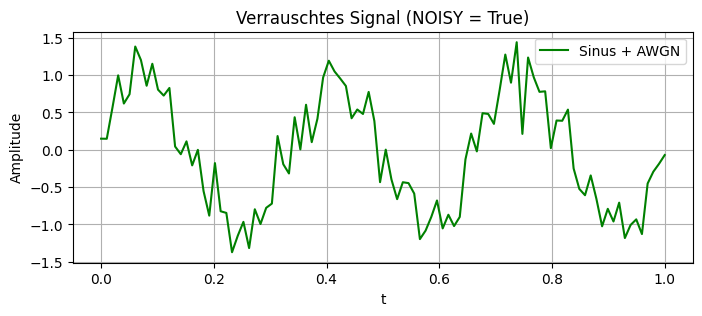

In [7]:
import numpy as np
import matplotlib.pyplot as plt

NOISY = True   # True = verrauschtes Signal plotten, False = nur Sinus

n = 100
t = np.linspace(0, 1, n)
f = 3
sinus = np.sin(2 * np.pi * f * t)
np.random.seed(42)
awgn = 0.3 * np.random.randn(n)

if NOISY:
    signal = sinus + awgn
    plt.figure(figsize=(8, 3))
    plt.plot(t, signal, color="green", label="Sinus + AWGN")
    plt.title("Verrauschtes Signal (NOISY = True)")
else:
    plt.figure(figsize=(8, 3))
    plt.plot(t, sinus, color="blue", label="Sinus")
    plt.title("Reines Sinussignal (NOISY = False)")

plt.xlabel("t")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Kurz zusammengefasst

| Thema | Inhalt |
|-------|--------|
| **bool** | `True` / `False`; Bedingungen liefern bool; Variablen wie NOISY machen Ablauf lesbar. |
| **if / else** | Bedingung mit `:`; Block durch Einrückung; in C: `()` und `{}`. |
| **Mehrere Fälle** | **elif** statt C-`switch`/`case`; optional später `match`/`case`. |
| **Beispiel** | 100 Punkte Sinus + AWGN; **NOISY** steuert, ob addiert und verrauscht geplottet wird; Zelle erneut ausführen und NOISY ändern. |

Damit kannst du Abläufe abhängig von Bedingungen steuern – und z. B. in Simulationen zwischen „nur Nutzsignal" und „Nutzsignal + Rauschen" umschalten.

---

**Weiter:** [→ 10_Tupels](../10_Tupels/10_Tupels.ipynb) – Tupel; danach [11_Funktionen](../11_Funktionen/11_Funktionen.ipynb) – Funktionen mit `def`.

**Zurück:** [← 08_Zufallszahlen](../08_Zufallszahlen/08_Zufallszahlen.ipynb)